# 02 — Process Performance Map (Camargo Sepsis)

Port of the henryk `02_process_performance_map` notebook, adapted for the Camargo `FullShared_Join_LSTM` baseline trained with the **paper-faithful n-gram=15 loader** (see `train_camargo_LSTM_ngram15.ipynb`). The earlier U-ED-LSTM-style windowing gave the model mostly EOS targets and no signal at short prefixes — this variant emits one training sample per time-step with the actual next activity as target.

- **Node label**: activity; color ∝ overall per-source-activity accuracy.
- **Edge label**: `correct / total` predictions for that directly-follows transition.
- **Edge color**: per-transition accuracy (green = high, red = low).

The Camargo model is a single-step next-activity predictor; we iterate prefixes (length 1..L-1) and call it once per prefix to build the performance map.

In [7]:
import sys
from pathlib import Path

# Locate project root and add needed paths
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils

project_root = _current
from src.interpretability.config.sepsis_config import CONFIG
CONFIG.use_improved = False  # set True for the improved variant

SPEC = utils.SEPSIS

model = utils.load_camargo_model(project_root, SPEC)
dataset = utils.load_test_dataset(project_root, SPEC)
# With ngram_size set, use that at inference so the input shape matches training.
window = SPEC.ngram_size or utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)
print(f'Loaded Camargo {SPEC.name} model | window={window} | vocab={predictor.n_classes} classes | |test|={len(dataset)}')

Data set categories:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('org:group', 27, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26})], [('case_elapsed_time', 1, {})])
Model input features:  [['concept:name', 'org:group'], ['case_elapsed_time']]
Embeddings:  ModuleList(
  (0): Embedding(18, 8)
  (1): Embedding(27, 10)
)
Total embedding feature size:  18
Number of numerical features:  1
Input feature size (shared LSTM, cat-only):  18
Cells hidden size:  50
Number of LSTM layer:  1
Loaded Camargo Sepsis model | window=5 | vocab=18 classes | 

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [8]:
records = utils.collect_prefix_predictions(predictor, dataset, progress=True, include_end=True)
print(f'Collected {len(records)} prefix predictions')
print(f"Overall accuracy: {sum(r['correct'] for r in records) / len(records) * 100:.1f}%")

Collected 2813 prefix predictions
Overall accuracy: 64.9%


In [9]:
# --- Overall accuracy summary ---
from collections import defaultdict
import pandas as pd

n_total = len(records)
n_correct = sum(1 for r in records if r['correct'])
overall = n_correct / n_total if n_total else 0.0
print(f'Overall next-activity accuracy: {n_correct}/{n_total} = {overall:.4f} ({overall*100:.2f}%)')

by_plen = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    by_plen[r['prefix_length']]['total'] += 1
    by_plen[r['prefix_length']]['correct'] += int(r['correct'])
rows = [{'prefix_length': pl, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']}
        for pl, v in sorted(by_plen.items())]
print('\nPer prefix-length:')
print(pd.DataFrame(rows).to_string(index=False))

if n_total and 'confidence' in records[0]:
    mean_conf = sum(r['confidence'] for r in records) / n_total
    print(f'\nMean top-1 confidence: {mean_conf*100:.2f}%')


Overall next-activity accuracy: 1827/2813 = 0.6495 (64.95%)

Per prefix-length:
 prefix_length  correct  total  accuracy
             1      191    209  0.913876
             2      174    209  0.832536
             3       97    209  0.464115
             4      126    199  0.633166
             5      143    199  0.718593
             6      116    181  0.640884
             7      143    177  0.807910
             8      113    173  0.653179
             9       62    146  0.424658
            10       97    138  0.702899
            11       60    124  0.483871
            12       66    120  0.550000
            13       66    102  0.647059
            14       50     86  0.581395
            15       37     67  0.552239
            16       34     56  0.607143
            17       29     44  0.659091
            18       26     39  0.666667
            19       16     34  0.470588
            20       17     31  0.548387
            21       17     26  0.653846
            22    

In [10]:
import pandas as pd
from collections import defaultdict

# Per-transition stats (source activity, actual next activity) -> total / correct
stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    key = (r['current_activity'], r['actual_next_activity'])
    stats[key]['total'] += 1
    stats[key]['correct'] += int(r['correct'])

# Per-source accuracy (node color)
node_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    node_stats[r['current_activity']]['total'] += 1
    node_stats[r['current_activity']]['correct'] += int(r['correct'])

rows = []
for (src, tgt), s in stats.items():
    rows.append({'source': src, 'target': tgt, 'correct': s['correct'], 'total': s['total'],
                 'accuracy': s['correct'] / s['total']})
transitions_df = pd.DataFrame(rows).sort_values(['source', 'total'], ascending=[True, False])
print(f'{len(transitions_df)} unique transitions')
with pd.option_context('display.max_rows', None):
    display(transitions_df)

93 unique transitions


,source,target,correct,total,accuracy
37,Admission IC,LacticAcid,7,9,0.777778
62,Admission IC,CRP,1,8,0.125000
27,Admission IC,Leucocytes,1,4,0.250000
14,Admission NC,Leucocytes,39,76,0.513158
17,Admission NC,CRP,23,64,0.359375
32,Admission NC,Admission NC,6,29,0.206897
8,Admission NC,Release A,2,24,0.083333
51,Admission NC,IV Liquid,0,5,0.000000
45,Admission NC,Release B,0,4,0.000000
44,Admission NC,LacticAcid,0,3,0.000000


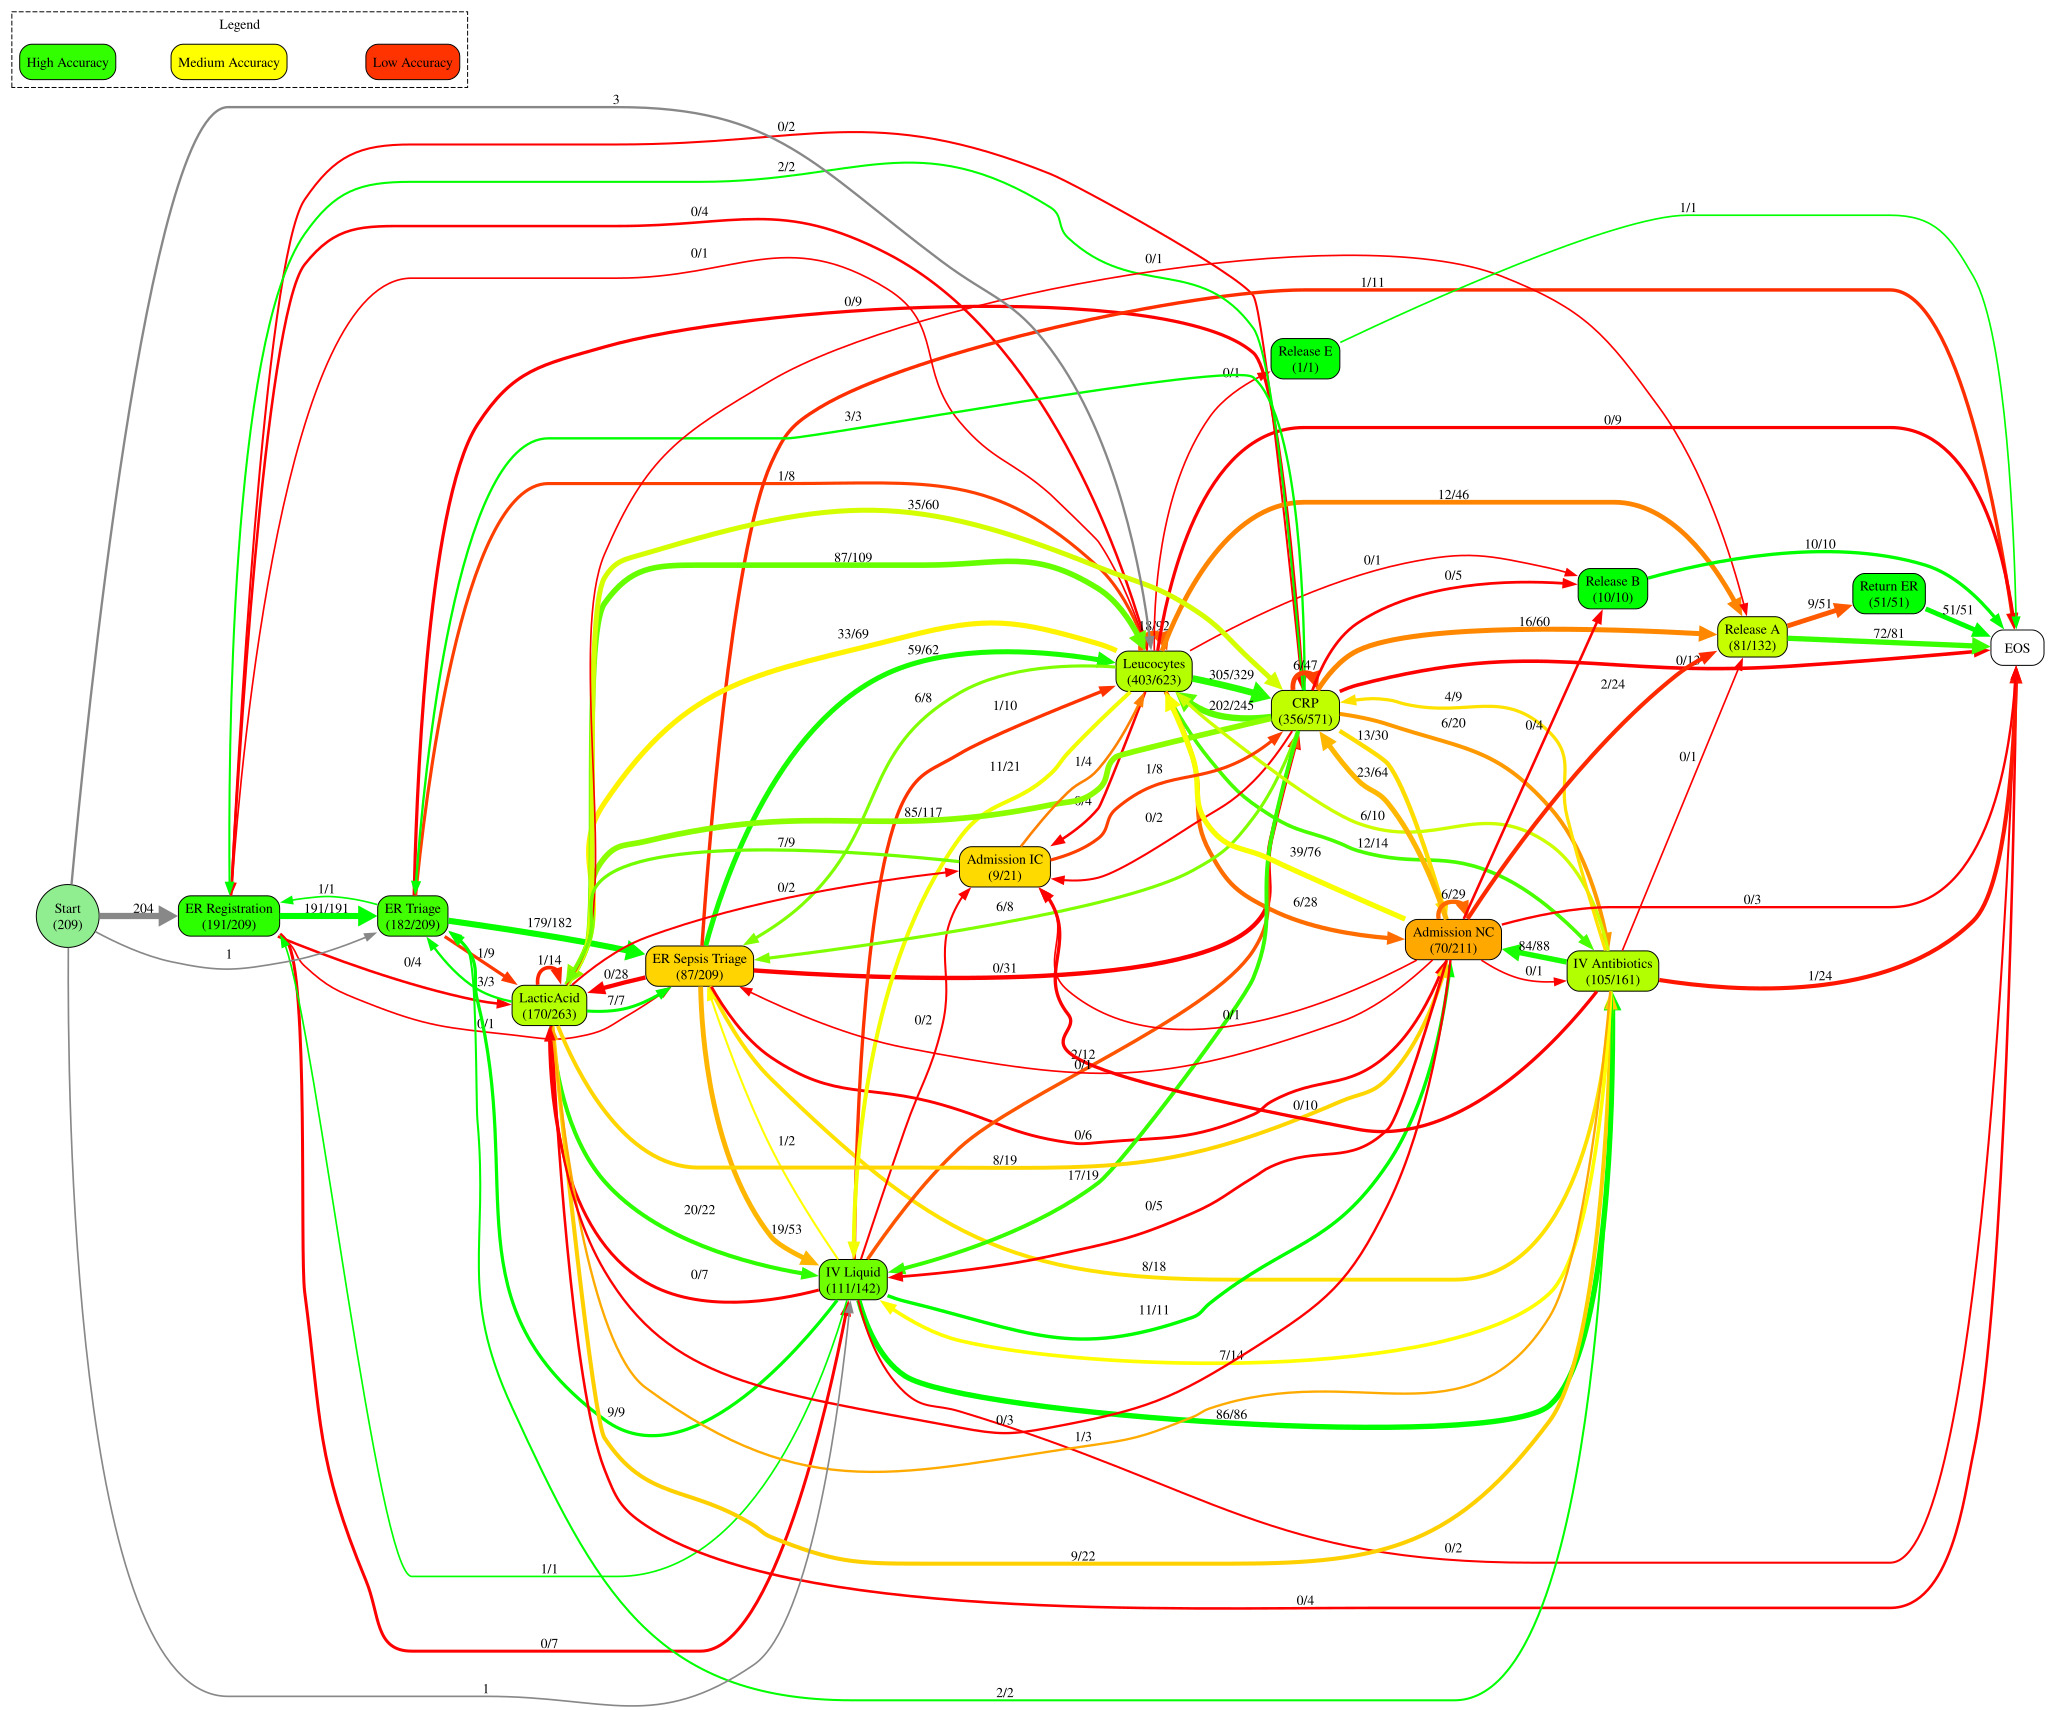

In [11]:
import graphviz
import math

MIN_EDGE_COUNT = 0  # raise to filter rare edges

def get_color_for_accuracy(accuracy: float) -> str:
    """Red (low) -> Yellow (mid) -> Green (high) gradient -- same as henryk/process_performance_map."""
    if accuracy < 0.5:
        r = 255
        g = int(255 * (accuracy * 2))
        b = 0
    else:
        r = int(255 * (1 - (accuracy - 0.5) * 2))
        g = 255
        b = 0
    return f'#{r:02x}{g:02x}{b:02x}'


dot = graphviz.Digraph(comment=f'Camargo {SPEC.name} Process Performance Map')
dot.attr(rankdir='LR')
dot.attr('node', shape='box', style='rounded,filled', fillcolor='white')

for act, s in node_stats.items():
    if s['total'] > 0:
        acc = s['correct'] / s['total']
        label = f"{act}\n({s['correct']}/{s['total']})"
        fill = get_color_for_accuracy(acc)
    else:
        label = str(act)
        fill = 'white'
    dot.node(str(act), label=label, fillcolor=fill)

start_counts = {}
for r in records:
    if r['prefix_length'] == 1:
        start_counts[r['current_activity']] = start_counts.get(r['current_activity'], 0) + 1
total_cases = sum(start_counts.values())
if total_cases:
    dot.node('__START__', label=f'Start\n({total_cases})', shape='circle', fillcolor='#90EE90', style='filled')
    for act, cnt in start_counts.items():
        if cnt >= MIN_EDGE_COUNT:
            dot.edge('__START__', str(act), label=str(cnt), color='#888888',
                     penwidth=str(1 + math.log1p(cnt)),
                     weight=str(int(math.log1p(cnt) * 10)))

for (src, tgt), s in stats.items():
    if s['total'] < MIN_EDGE_COUNT:
        continue
    acc = s['correct'] / s['total']
    color = get_color_for_accuracy(acc)
    label = f"{s['correct']}/{s['total']}"
    # Edge weight = log(count) so dot's ranker pulls the heaviest path into a
    # straight horizontal trunk; self-loops use constraint=false so they don't
    # shift ranks. Mirrors the henryk PPM visualizer for layout consistency.
    edge_kwargs = {
        'label': label, 'color': color,
        'penwidth': str(1 + math.log1p(s['total'])),
        'weight': str(int(math.log1p(s['total']) * 10)),
    }
    if src == tgt:
        edge_kwargs['constraint'] = 'false'
    dot.edge(str(src), str(tgt), **edge_kwargs)

with dot.subgraph(name='cluster_legend') as legend:
    legend.attr(label='Legend', style='dashed')
    legend.node('high_acc', 'High Accuracy', fillcolor=get_color_for_accuracy(0.9))
    legend.node('mid_acc', 'Medium Accuracy', fillcolor=get_color_for_accuracy(0.5))
    legend.node('low_acc', 'Low Accuracy', fillcolor=get_color_for_accuracy(0.1))
    legend.edge('high_acc', 'mid_acc', style='invis')
    legend.edge('mid_acc', 'low_acc', style='invis')

dot

In [12]:
# Per-source summary
print('Per-source-activity accuracy:')
for act, s in sorted(node_stats.items(), key=lambda x: -x[1]['total']):
    acc = s['correct'] / s['total']
    print(f"  {act:<30s} {s['correct']:5d}/{s['total']:<5d}  {acc * 100:5.1f}%")

Per-source-activity accuracy:
  Leucocytes                       403/623     64.7%
  CRP                              356/571     62.3%
  LacticAcid                       170/263     64.6%
  Admission NC                      70/211     33.2%
  ER Registration                  191/209     91.4%
  ER Triage                        182/209     87.1%
  ER Sepsis Triage                  87/209     41.6%
  IV Antibiotics                   105/161     65.2%
  IV Liquid                        111/142     78.2%
  Release A                         81/132     61.4%
  Return ER                         51/51     100.0%
  Admission IC                       9/21      42.9%
  Release B                         10/10     100.0%
  Release E                          1/1      100.0%
